# Principal Component Analysis with Cancer Data

In [28]:
#Import all the necessary modules
#Import all the necessary modules
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.stats import zscore

# Q1. Load the Data file into Python DataFrame and view top 10 rows

In [67]:
# Read the dataset
dataset = pd.read_csv("breast-cancer-wisconsin-data.csv")
dataset.head()

,ID,ClumpThickness,Cell Size,Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Normal Nucleoli,Bland Chromatin,Mitoses,Class
0,1000025,5,1,1,1,2,1,3,1,1,2
1,1002945,5,4,4,5,7,10,3,2,1,2
2,1015425,3,1,1,1,2,2,3,1,1,2
3,1016277,6,8,8,1,3,4,3,7,1,2
4,1017023,4,1,1,3,2,1,3,1,1,2


In [0]:
  # Id columns is to identify rows hence can be skipped in analysis
  # All columns have numerical values
  # Class would be the target variable. Should be removed when PCA is done

# Q2 Print the datatypes of each column and the shape of the dataset. Perform descriptive analysis 

In [23]:
dataset.info()
dataset.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 699 entries, 0 to 698
Data columns (total 11 columns):
ID                             699 non-null int64
ClumpThickness                 699 non-null int64
Cell Size                      699 non-null int64
Cell Shape                     699 non-null int64
Marginal Adhesion              699 non-null int64
Single Epithelial Cell Size    699 non-null int64
Bare Nuclei                    699 non-null object
Normal Nucleoli                699 non-null int64
Bland Chromatin                699 non-null int64
Mitoses                        699 non-null int64
Class                          699 non-null int64
dtypes: int64(10), object(1)
memory usage: 60.1+ KB


(699, 11)

# Q3 Check for missing value check, incorrect data, duplicate data and perform imputation with mean, median, mode as necessary.


In [53]:
df = dataset.drop(labels=['ID','Class'], axis=1)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 699 entries, 0 to 698
Data columns (total 9 columns):
ClumpThickness                 699 non-null int64
Cell Size                      699 non-null int64
Cell Shape                     699 non-null int64
Marginal Adhesion              699 non-null int64
Single Epithelial Cell Size    699 non-null int64
Bare Nuclei                    699 non-null object
Normal Nucleoli                699 non-null int64
Bland Chromatin                699 non-null int64
Mitoses                        699 non-null int64
dtypes: int64(8), object(1)
memory usage: 49.2+ KB


In [54]:
df.isnull().sum()

ClumpThickness                 0
Cell Size                      0
Cell Shape                     0
Marginal Adhesion              0
Single Epithelial Cell Size    0
Bare Nuclei                    0
Normal Nucleoli                0
Bland Chromatin                0
Mitoses                        0
dtype: int64

In [55]:
df['Bare Nuclei'] = df['Bare Nuclei'].replace('?', np.nan)

In [56]:
# No missing values found. So let us try to remove ? from bare nuclei column

# Get count of rows having ?
df['Bare Nuclei'] = df['Bare Nuclei'].astype('float64')

In [57]:
# 16 values are corrupted. We can either delete them as it forms roughly 2% of data.
# Here we would like to impute it with suitable values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 699 entries, 0 to 698
Data columns (total 9 columns):
ClumpThickness                 699 non-null int64
Cell Size                      699 non-null int64
Cell Shape                     699 non-null int64
Marginal Adhesion              699 non-null int64
Single Epithelial Cell Size    699 non-null int64
Bare Nuclei                    683 non-null float64
Normal Nucleoli                699 non-null int64
Bland Chromatin                699 non-null int64
Mitoses                        699 non-null int64
dtypes: float64(1), int64(8)
memory usage: 49.2 KB


In [58]:
df.describe()

,ClumpThickness,Cell Size,Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Normal Nucleoli,Bland Chromatin,Mitoses
count,699.000000,699.000000,699.000000,699.000000,699.000000,683.000000,699.000000,699.000000,699.000000
mean,4.417740,3.134478,3.207439,2.806867,3.216023,3.544656,3.437768,2.866953,1.589413
std,2.815741,3.051459,2.971913,2.855379,2.214300,3.643857,2.438364,3.053634,1.715078
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,2.000000,1.000000,1.000000,1.000000,2.000000,1.000000,2.000000,1.000000,1.000000
50%,4.000000,1.000000,1.000000,1.000000,2.000000,1.000000,3.000000,1.000000,1.000000
75%,6.000000,5.000000,5.000000,4.000000,4.000000,6.000000,5.000000,4.000000,1.000000
max,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000


# Q4. Perform bi variate analysis including correlation & pairplots. 


In [0]:
# Check for correlation of variable

In [0]:
# Cell size shows high significance with cell shape,marginal adhesion, single epithelial cell size,bare nuclei, normal nucleoli 
# and bland chromatin
# Target variable shows high correlation with most of these variables

In [0]:
#Let us check for pair plots

In [59]:
df.corr()

,ClumpThickness,Cell Size,Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Normal Nucleoli,Bland Chromatin,Mitoses
ClumpThickness,1.000000,0.644913,0.654589,0.486356,0.521816,0.593091,0.558428,0.535835,0.350034
Cell Size,0.644913,1.000000,0.906882,0.705582,0.751799,0.691709,0.755721,0.722865,0.458693
Cell Shape,0.654589,0.906882,1.000000,0.683079,0.719668,0.713878,0.735948,0.719446,0.438911
Marginal Adhesion,0.486356,0.705582,0.683079,1.000000,0.599599,0.670648,0.666715,0.603352,0.417633
Single Epithelial Cell Size,0.521816,0.751799,0.719668,0.599599,1.000000,0.585716,0.616102,0.628881,0.479101
Bare Nuclei,0.593091,0.691709,0.713878,0.670648,0.585716,1.000000,0.680615,0.584280,0.339210
Normal Nucleoli,0.558428,0.755721,0.735948,0.666715,0.616102,0.680615,1.000000,0.665878,0.344169
Bland Chromatin,0.535835,0.722865,0.719446,0.603352,0.628881,0.584280,0.665878,1.000000,0.428336
Mitoses,0.350034,0.458693,0.438911,0.417633,0.479101,0.339210,0.344169,0.428336,1.000000


C:\Users\MAYUR-PC\Anaconda3\lib\site-packages\scipy\stats\stats.py:1713: FutureWarning: Using a non-tuple sequence for multidimensional indexing is deprecated; use `arr[tuple(seq)]` instead of `arr[seq]`. In the future this will be interpreted as an array index, `arr[np.array(seq)]`, which will result either in an error or a different result.
  return np.add.reduce(sorted[indexer] * weights, axis=axis) / sumval
C:\Users\MAYUR-PC\Anaconda3\lib\site-packages\statsmodels\nonparametric\kde.py:448: RuntimeWarning: invalid value encountered in greater
  X = X[np.logical_and(X > clip[0], X < clip[1])] # won't work for two columns.
C:\Users\MAYUR-PC\Anaconda3\lib\site-packages\statsmodels\nonparametric\kde.py:448: RuntimeWarning: invalid value encountered in less
  X = X[np.logical_and(X > clip[0], X < clip[1])] # won't work for two columns.


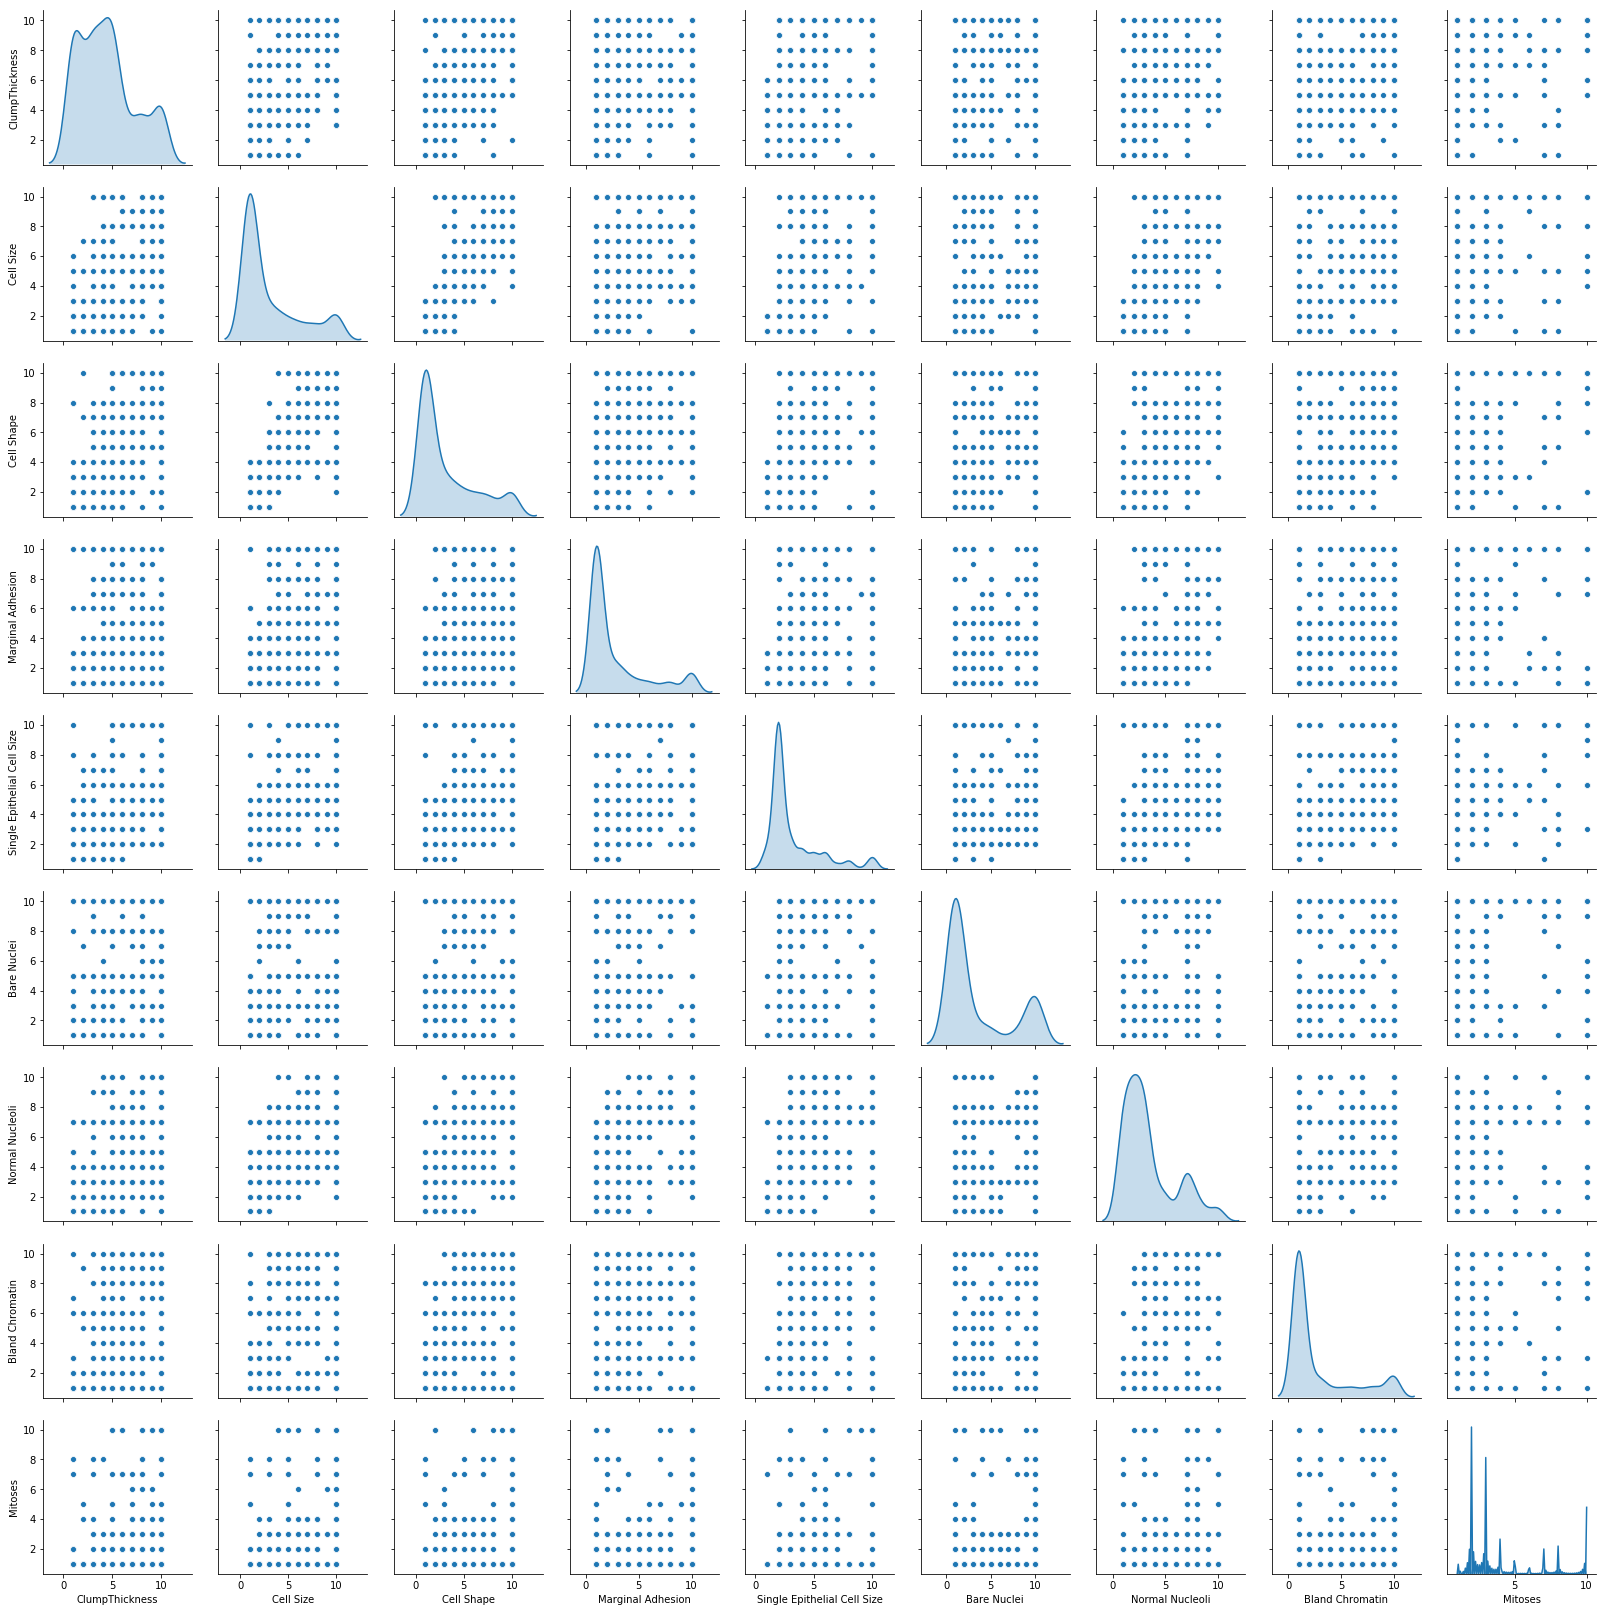

In [65]:

sns.pairplot( df, diag_kind='kde')



# Q5 Remove any unwanted columns or outliers, standardize variables in this pre-processing step

In [0]:
# We could see most of the outliers are now removed.

In [74]:
df.drop_duplicates(inplace = True)

In [77]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 463 entries, 0 to 698
Data columns (total 9 columns):
ClumpThickness                 463 non-null int64
Cell Size                      463 non-null int64
Cell Shape                     463 non-null int64
Marginal Adhesion              463 non-null int64
Single Epithelial Cell Size    463 non-null int64
Bare Nuclei                    449 non-null float64
Normal Nucleoli                463 non-null int64
Bland Chromatin                463 non-null int64
Mitoses                        463 non-null int64
dtypes: float64(1), int64(8)
memory usage: 36.2 KB


In [85]:
df = df.fillna(df.mean())
df

,ClumpThickness,Cell Size,Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Normal Nucleoli,Bland Chromatin,Mitoses
0,5,1,1,1,2,1.000000,3,1,1
1,5,4,4,5,7,10.000000,3,2,1
2,3,1,1,1,2,2.000000,3,1,1
3,6,8,8,1,3,4.000000,3,7,1
4,4,1,1,3,2,1.000000,3,1,1
5,8,10,10,8,7,10.000000,9,7,1
6,1,1,1,1,2,10.000000,3,1,1
7,2,1,2,1,2,1.000000,3,1,1
8,2,1,1,1,2,1.000000,1,1,5
9,4,2,1,1,2,1.000000,2,1,1


# Q6 Create a covariance matrix for identifying Principal components

In [0]:
# PCA
# Step 1 - Create covariance matrix


In [86]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X,y = df.iloc[:, 1:].values , df.iloc[:,0].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5 , random_state=0)
sc = StandardScaler()
X_train_std = sc.fit_transform(X_train)
X_test_std = sc.fit_transform(X_test)

In [87]:
cov_matrix = np.cov(X_train_std.T)

print('Covariance Matrix \n%s', cov_matrix)

Covariance Matrix 
%s [[1.00434783 0.89173045 0.59405376 0.6852623  0.60924907 0.69964122
  0.66958573 0.45701485]
 [0.89173045 1.00434783 0.58922426 0.66453161 0.61028205 0.6576613
  0.68119889 0.45716944]
 [0.59405376 0.58922426 1.00434783 0.49066219 0.59487512 0.6116633
  0.53191778 0.39310334]
 [0.6852623  0.66453161 0.49066219 1.00434783 0.50836635 0.57992752
  0.55903022 0.54529795]
 [0.60924907 0.61028205 0.59487512 0.50836635 1.00434783 0.58785814
  0.51628376 0.34240511]
 [0.69964122 0.6576613  0.6116633  0.57992752 0.58785814 1.00434783
  0.64805982 0.39070672]
 [0.66958573 0.68119889 0.53191778 0.55903022 0.51628376 0.64805982
  1.00434783 0.4461756 ]
 [0.45701485 0.45716944 0.39310334 0.54529795 0.34240511 0.39070672
  0.4461756  1.00434783]]


# Q7 Identify eigen values and eigen vector

In [0]:
# Step 2- Get eigen values and eigen vector

In [88]:
eig_vals, eig_vecs = np.linalg.eig(cov_matrix)
print('Eigen Vectors \n%s', eig_vecs)
print('\n Eigen Values \n%s', eig_vals)

Eigen Vectors 
%s [[-0.39897633  0.06137874 -0.72032285 -0.34011327 -0.17784091 -0.24519438
   0.29779454 -0.14859084]
 [-0.39497512  0.05649321  0.68250692 -0.34141822 -0.17601696 -0.15824361
   0.44144795 -0.08672812]
 [-0.33620777  0.26127769 -0.01135289  0.59569246  0.2289243   0.24989582
   0.21694091 -0.54936535]
 [-0.35308931 -0.32249334  0.03369172 -0.17134838 -0.41618069  0.48836582
  -0.50398642 -0.27408163]
 [-0.33460148  0.35019657 -0.02046961  0.40902381 -0.46614076  0.02885081
  -0.05110299  0.6139655 ]
 [-0.36602048  0.214229    0.10308803 -0.03325724  0.32319442 -0.55450908
  -0.62497218 -0.07665887]
 [-0.35629419  0.01025372 -0.05448652 -0.27084929  0.61549371  0.48103468
   0.05660067  0.42800782]
 [-0.27245206 -0.80754959 -0.00635224  0.37653809  0.10584702 -0.27236471
   0.13773552  0.16569565]]

 Eigen Values 
%s [5.05701536 0.77040936 0.10860681 0.56726499 0.46192766 0.31412506
 0.36504693 0.39038643]


In [89]:
print("Eigen Values:")
pd.DataFrame(eig_vals).transpose()

Eigen Values:


,0,1,2,3,4,5,6,7
0,5.057015,0.770409,0.108607,0.567265,0.461928,0.314125,0.365047,0.390386


# Q8 Find variance and cumulative variance by each eigen vector

In [90]:
tot = sum(eig_vals)
var_exp = [( i /tot ) * 100 for i in sorted(eig_vals, reverse=True)]
cum_var_exp = np.cumsum(var_exp)
print("Cumulative Variance Explained", cum_var_exp)

Cumulative Variance Explained [ 62.93904398  72.52747219  79.58758847  85.33668811  90.19539373
  94.73872671  98.64829185 100.        ]


# Q9 Use PCA command from sklearn and find Principal Components. Transform data to components formed

In [92]:
from sklearn.decomposition import PCA

In [93]:
X_centered = X - X.mean(axis=0)

In [94]:
pca = PCA(n_components=2)
pca.fit(X_centered)

PCA(copy=True, iterated_power='auto', n_components=2, random_state=None,
  svd_solver='auto', tol=0.0, whiten=False)

In [95]:
X_pca = pca.transform(X_centered)

In [96]:
X_pca.shape

(463, 2)

In [97]:
pca.components_

array([[ 0.42473262,  0.40578056,  0.35902931,  0.26518246,  0.43680709,
         0.3130769 ,  0.38514855,  0.13624818],
       [ 0.21749777,  0.1545465 , -0.13824442,  0.18124214, -0.80186838,
        -0.00254549,  0.45349291,  0.16791267]])

# Q10 Find correlation between components and features

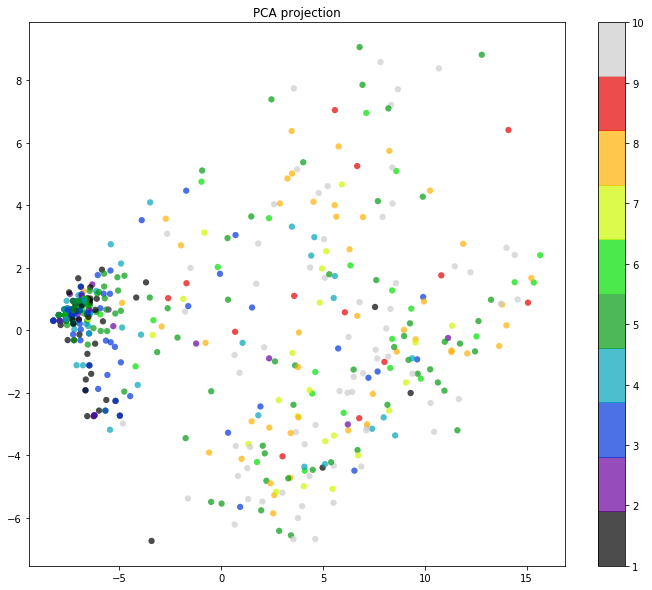

In [100]:
plt.figure(figsize=(12,10))

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, 
            edgecolor='none', alpha=0.7, s=40,
            cmap=plt.cm.get_cmap('nipy_spectral', 10))

plt.colorbar()

plt.title('PCA projection')

plt.show()

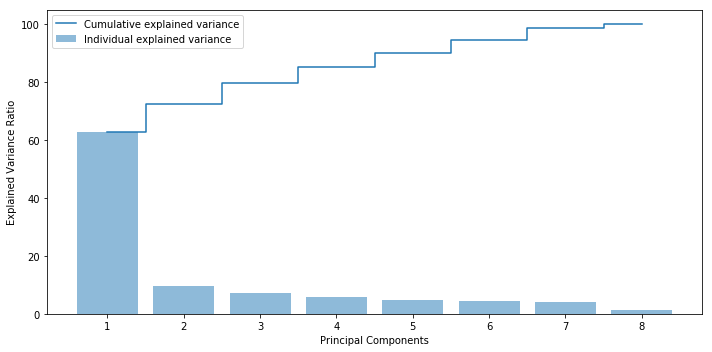

In [101]:
# Ploting 
plt.figure(figsize=(10 , 5))
plt.bar(range(1, eig_vals.size + 1), var_exp, alpha = 0.5, align = 'center', label = 'Individual explained variance')
plt.step(range(1, eig_vals.size + 1), cum_var_exp, where='mid', label = 'Cumulative explained variance')
plt.ylabel('Explained Variance Ratio')
plt.xlabel('Principal Components')
plt.legend(loc = 'best')
plt.tight_layout()
plt.show()